### Codigo 03 - Undersampling, Oversampling e SMOTE

Neste notebook, vamos aplicar tecnicas de reamostragem para lidar com dados desbalanceados.

A regra mais importante e: aplique undersampling, oversampling ou SMOTE somente no conjunto de treino. O conjunto de teste precisa continuar original para representar melhor o mundo real.

### 1. Instalacao do pacote necessario

As tecnicas RandomUnderSampler, RandomOverSampler e SMOTE ficam no pacote imbalanced-learn.

Se aparecer erro dizendo que imblearn nao existe, rode a linha abaixo em uma celula do notebook:

In [1]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


### 2. Importacoes

Agora importamos as bibliotecas. Vamos usar pandas, scikit-learn e imbalanced-learn.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split

### 3. Configuracoes da base

Vamos trabalhar com a base Covertype. O arquivo esperado e cov_types.csv. Se ele nao existir, o notebook tentara baixar a base oficial da UCI.

In [3]:
CSV_PATH = Path("cov_types.csv")
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
RANDOM_STATE = 42
SAMPLE_SIZE = 30_000

COLUNAS = (
    [
        "Elevation",
        "Aspect",
        "Slope",
        "Horizontal_Distance_To_Hydrology",
        "Vertical_Distance_To_Hydrology",
        "Horizontal_Distance_To_Roadways",
        "Hillshade_9am",
        "Hillshade_Noon",
        "Hillshade_3pm",
        "Horizontal_Distance_To_Fire_Points",
    ]
    + [f"Wilderness_Area{i}" for i in range(1, 5)]
    + [f"Soil_Type{i}" for i in range(1, 41)]
    + ["Cover_Type"]
)

### 4. Funcao para carregar a base

Esta funcao evita repeticao de codigo. Ela carrega cov_types.csv se o arquivo existir. Caso contrario, baixa a base original da UCI e salva localmente.

In [4]:
def carregar_base() -> pd.DataFrame:
    """Carrega cov_types.csv ou baixa a base oficial."""
    if CSV_PATH.exists():
        print(f"Lendo arquivo local: {CSV_PATH.resolve()}")
        return pd.read_csv(CSV_PATH)
    
    print("Arquivo cov_types.csv nao encontrado.")
    print("Baixando a base oficial Covertype da UCI...")

    df = pd.read_csv(UCI_URL, header=None, names=COLUNAS, compression='gzip')
    df.to_csv(CSV_PATH, index=False)

    print(f"Arquivo salvo em: {CSV_PATH.resolve()}")
    return df

### 5. Carregando os dados e separando X e y

Agora carregamos a base e separamos as variaveis explicativas X da variavel alvo y.
A coluna alvo e Cover_Type, que representa a classe que queremos prever.

In [5]:
df = carregar_base()

print("Formato original:", df.shape)
display(df.head())

if len(df) > SAMPLE_SIZE:
    df =- df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
    print(f"Usando amostra de {SAMPLE_SIZE} linhas para treinar mais rápido.")

X = df.drop(columns="Cover_Type")
y = df['Cover_Type']

print("Formato de X", X.shape)
print("Formato de y", y.shape)


Lendo arquivo local: C:\Users\Olive\VS Code\Python\meu-projeto\machine_learning_and_Data_Science\9_dados_desbalanceados\cov_types.csv
Formato original: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


Usando amostra de 30000 linhas para treinar mais rápido.
Formato de X (30000, 54)
Formato de y (30000,)


### 6. Verificando a distribuicao original das classes

Antes de balancear, precisamos entender o tamanho de cada classe. O grafico ajuda a enxergar o desbalanceamento rapidamente.

,quantidade,percentual
Cover_Type,,
-7,1037,3.46
-6,901,3.00
-5,473,1.58
-4,137,0.46
-3,1830,6.10
-2,14558,48.53
-1,11064,36.88


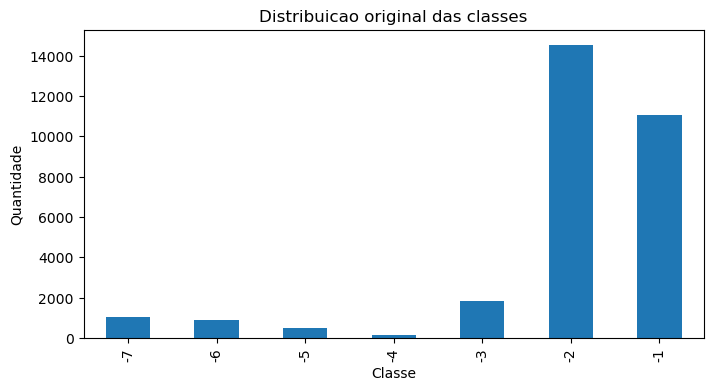

In [8]:
distribuicao = pd.DataFrame(
    {
        "quantidade": y.value_counts().sort_index(),
        "percentual": (y.value_counts(normalize=True).sort_index() * 100).round(2),
    }
)

display(distribuicao)

distribuicao["quantidade"].plot(kind="bar", figsize=(8, 4), title="Distribuicao original das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

### 7. Separando treino e teste antes do balanceamento
Este e o ponto mais importante do notebook: primeiro separamos treino e teste. Depois aplicamos reamostragem apenas no treino.
Se balancearmos a base inteira antes da separacao, criamos vazamento de dados e a avaliacao fica artificialmente boa.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Treino:', X_train.shape)
print('Treino:', X_test.shape)

print("\nDistribuicao no treino:")
print(y_train.value_counts().sort_index())

print("\nDistribuicao no teste original:")
print(y_test.value_counts().sort_index())

Treino: (24000, 54)
Treino: (6000, 54)

Distribuicao no treino:
Cover_Type
-7      830
-6      721
-5      378
-4      110
-3     1464
-2    11646
-1     8851
Name: count, dtype: int64

Distribuicao no teste original:
Cover_Type
-7     207
-6     180
-5      95
-4      27
-3     366
-2    2912
-1    2213
Name: count, dtype: int64


### 8. Funcoes auxiliares
Vamos criar duas funcoes: uma para mostrar a distribuicao das classes e outra para treinar/avaliar um modelo.
Usaremos sempre o mesmo RandomForestClassifier para comparar as tecnicas de forma mais justa.

In [11]:
def mostrar_distribuicao(nome: str, y_valores: pd.Series) -> None:
    """Mostra a quantidade de exemplos por classe."""
    print("\n" + "-" * 80)
    print(nome)
    print("-" * 80)
    print(pd.Series(y_valores).value_counts().sort_index())


def criar_modelo() -> RandomForestClassifier:
    """Cria sempre o mesmo modelo para a comparacao ser justa."""
    return RandomForestClassifier(
        n_estimators=60,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def treinar_e_avaliar(nome: str, X_treino, y_treino, X_teste, y_teste) -> dict:
    """Treina um RandomForest e imprime as metricas principais."""
    modelo = criar_modelo()
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    balanced_acc = balanced_accuracy_score(y_teste, pred)

    print("\n" + "=" * 80)
    print(nome)
    print("=" * 80)
    print("Balanced accuracy:", round(balanced_acc, 4))
    print(classification_report(y_teste, pred))

    return {
        "tecnica": nome,
        "balanced_accuracy": balanced_acc,
    }

### 9. Baseline sem reamostragem
Antes de aplicar qualquer tecnica, treinamos um modelo sem balanceamento. Ele sera nossa referencia.
Sem baseline, fica dificil saber se a tecnica realmente ajudou.

In [ ]:
resultados = []

resultados.append(
    treinar_e_avaliar(
        "1. Baseline sem reamostragem",
        X_train,
        y_train,
        X_test,
        y_test,

    )
)


1. Baseline sem reamostragem
Balanced accuracy: 0.6974
              precision    recall  f1-score   support

          -7       0.93      0.79      0.86       207
          -6       0.80      0.61      0.69       180
          -5       0.88      0.39      0.54        95
          -4       0.64      0.52      0.57        27
          -3       0.79      0.83      0.81       366
          -2       0.85      0.90      0.88      2912
          -1       0.86      0.84      0.85      2213

    accuracy                           0.85      6000
   macro avg       0.82      0.70      0.74      6000
weighted avg       0.85      0.85      0.85      6000



### 10. RandomUnderSampler
O undersampling reduz a quantidade de exemplos das classes maiores.
Vantagem: o treino fica mais rapido e as classes ficam equilibradas.
Risco: podemos jogar fora informacao importante da classe majoritaria.